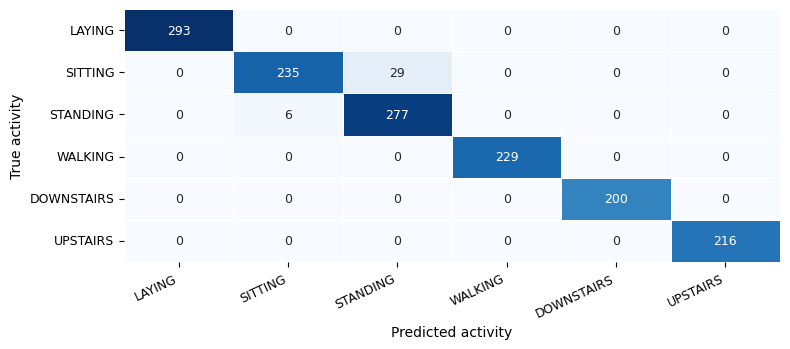

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Confusion Matrix laden
# Falls das Notebook im selben Ordner wie die CSV liegt, reicht dieser Dateiname.
csv_path = Path("final_two_stage_test_confusion_matrix.csv")

cm = pd.read_csv(csv_path, index_col=0)

# Labels bereinigen
cm.index = cm.index.str.replace("True: ", "", regex=False)
cm.columns = cm.columns.str.replace("Pred: ", "", regex=False)

# Lange Labels kürzen, damit die Abbildung im Paper lesbar bleibt
short_labels = {
    "WALKING_DOWNSTAIRS": "DOWNSTAIRS",
    "WALKING_UPSTAIRS": "UPSTAIRS"
}

cm = cm.rename(index=short_labels, columns=short_labels)

# Kompakte Heatmap erstellen:
# gleiche Breite wie vorher, aber geringere Höhe
plt.figure(figsize=(8, 3.6))

ax = sns.heatmap(
    cm,
    annot=True,              # Zahlen in die Felder schreiben
    fmt="d",                 # Ganzzahlen anzeigen
    cmap="Blues",            # Farbschema
    cbar=False,              # spart Platz; Zahlen stehen direkt in der Matrix
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 9}
)

# Für das Paper reicht die Caption unter der Abbildung.
# Deshalb kein Titel in der Grafik selbst.
ax.set_xlabel("Predicted activity", fontsize=10)
ax.set_ylabel("True activity", fontsize=10)

plt.xticks(rotation=25, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()

# Für Word/Paper in hoher Auflösung speichern
plt.savefig("confusion_matrix_heatmap_compact.png", dpi=300, bbox_inches="tight")
plt.savefig("confusion_matrix_heatmap_compact.pdf", bbox_inches="tight")

plt.show()